# Pensions

## 0.1.Import Packages

In [49]:
import pandas as pd
import sys
import numpy as np
import seaborn as sns
# import for auto-suggestions for objects
import pydot
import pyreadline
# import for sigmoid-fct.
import scipy
import scipy.special
from scipy import stats
from scipy.stats import gamma, truncnorm, describe
import sklearn
from sklearn import preprocessing, cluster
from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV
# import for plotting
import matplotlib.pyplot as plt
%matplotlib inline
import random
import time
import decimal
import json # to save history objects of keras models
import pickle # to save general objects, e.g. K-Means Clustering Object
import os

import tensorflow as tf
import keras
from keras import backend as K
from tensorflow.keras import layers
from keras.models import Sequential, Model, load_model
from keras.optimizers import Adam, SGD, Adadelta
from keras.layers import Dense, Flatten, Dropout, multiply, dot, Activation
from keras.layers import ThresholdedReLU, RepeatVector, add, concatenate, Reshape
from keras.layers import RNN, SimpleRNN,GRU, LSTM,CuDNNLSTM, Reshape, Lambda, InputLayer, Input, BatchNormalization, Average, average
from keras.layers import advanced_activations as adv_act
from keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping
from keras.utils import plot_model, print_summary
from keras.wrappers.scikit_learn import KerasClassifier, KerasRegressor
import seaborn as sb
import sobol_seq

## 0.2. Load Functions

In [2]:
# Functions
%run functions/actuarial_functions.ipynb
%run functions/rnn_functions.ipynb
%run functions/visualization_functions.ipynb
%run functions/statistical_analysis_functions.ipynb
%run functions/clustering.ipynb

# Simulation of Data&Targets
%run Data/data_part1_simulation_feature_space.ipynb
%run Data/data_part2_calculation_targets.ipynb

# Data Preparation
%run Data/data_prep_General.ipynb
%run Data/data_prep_RNN_data_transformation.ipynb

# Single-dimensional data analysis
%run data_analysis_single_dimension/models_1dim_FFN.ipynb

# 1. Assumptions

In [3]:
# Portfolio Details
N_contracts = 100000 
input_used = ['Fund','Age', 'Salary', 'Salary_scale', 'Contribution']#, 'interest_rate']
n_in = len(input_used)

pension_age_max = 67

In [4]:
# current directory for saving issues
cd = r"C:\Users\mark.kiermayer\Documents\Promotion\Python Scripts\Paper (Grouping) - Code\Pensions"
# dummy if saved models should be loaded (TRUE) or the all models should be recalculated (False)
dummy_load_saved_models = True

# Dataframe representation
pd.set_option('precision', 2)
pd.set_option('display.max_colwidth', 40)

In [5]:
# Makeham mortality model
A= 0.00022
B=2.7*10**(-6)
c=1.124

early_pension_structure = [0.3, 0.1, 0.1, 0.1, 0.1, 0.1]

# Split ration training and test data
ratio_tr_tst = 0.7
N_train = int(ratio_tr_tst*N_contracts)

# share of validation data
val_share = 0.25

In [6]:
# Range of Variables
age_min, age_max = 25,60
fund_min, fund_max = 0, 500000
salary_min, salary_max = 20000, 200000
salary_scale_min, salary_scale_max = 0.01, 0.05
contribution_min, contribution_max = 0.01, 0.1
#int_min, int_max = -0.01, 0.10
interest_rate = 0.03 # fixed interest rate

# Matrix Version of previous upper/ lower bounds on features
Min_Max = np.array([fund_min, fund_max, age_min, age_max, salary_min, salary_max, 
                    salary_scale_min, salary_scale_max,
                    contribution_min, contribution_max]).reshape(n_in,2)#, int_min, int_max])

# 2. Simulation of Data

## 2.1. Raw Data

In [7]:
random.seed(42)
data_sc = 2*sobol_seq.i4_sobol_generate(dim_num = n_in, n = N_contracts)-1   # in [-1,+1]

In [8]:
data = (data_sc+1)/2*(Min_Max[:,1]-Min_Max[:,0])+Min_Max[:,0]

In [9]:
%run functions/actuarial_functions.ipynb

In [10]:
targets = pension_reserve(data, pension_age_max=pension_age_max, age_min=age_min, interest_std = interest_rate, 
                          ep_structure= early_pension_structure)

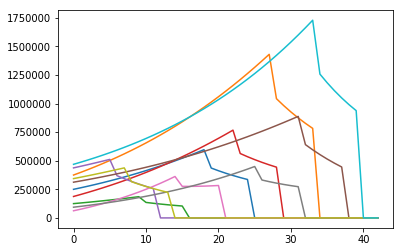

In [11]:
for i in range(10):
    plt.plot(targets[i,:])

## 2.2. Train-/ Test-Split

In [12]:
# Complete Data
data_train,data_test = data_prep_split(data,ratio_tr_tst)
data_train_sc, data_test_sc = data_prep_split(data_sc, ratio_tr_tst)
targets_train, targets_test= data_prep_split(targets,ratio_tr_tst)

# 3. Analysis of Data/ Targets

In [13]:
V_max = get_pension_reserve(fund_accum = fund_max, age = age_min, salary = salary_max, 
                            salary_scale = salary_scale_max, contribution = contribution_max, 
                             A = 0.00022, B = 2.7*10**(-6), c = 1.124, interest = interest_rate,
                            pension_age_max = 67, early_pension = early_pension_structure).max()

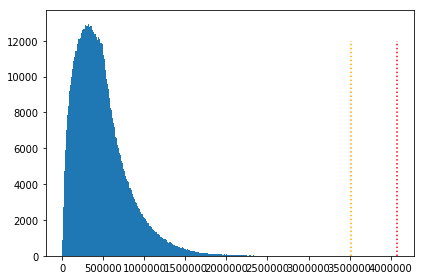

0.4186072093023256

In [14]:
plt.hist(targets[targets!=0].flatten(), bins = 1000)
plt.vlines(x = V_max, ymin = 0, ymax= 12000,linestyle = 'dotted', color = 'red')
plt.vlines(x = targets.max(), ymin = 0, ymax= 12000, linestyle = 'dotted', color = 'orange')
plt.tight_layout()
plt.show()
(targets==0).sum()/(N_contracts*(pension_age_max-age_min+1))

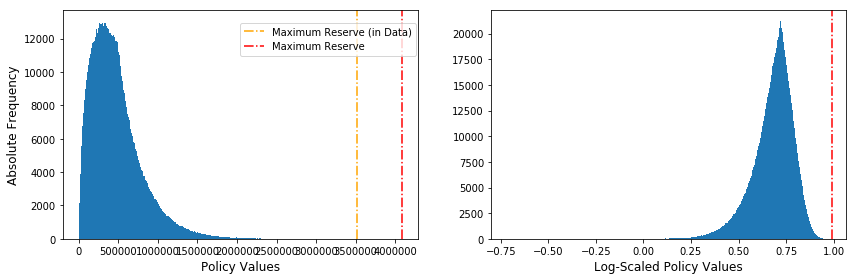

In [15]:
# Check Scaling feature of multivariate data

fig, [ax1, ax2] = plt.subplots(1,2, figsize = (12,4))
ax1.hist(targets[targets!=0], bins = 1000, density = False)
ax1.axvline(targets.max(axis=1).max(),color = 'orange', linestyle = '-.', label = 'Maximum Reserve (in Data)')
ax1.axvline(V_max,color = 'red', linestyle = '-.', label = 'Maximum Reserve')

ax1.legend(loc=(0.5,0.8))
ax1.set_ylabel('Absolute Frequency', fontsize = 'large')
ax1.set_xlabel('Policy Values', fontsize = 'large')
#ax1.set_title('Histogram of maximal reserves per contract')

ax2.hist(2*np.log(1+targets[targets!=0])/np.log(1+V_max)-1, bins = 1000, density=False)
ax2.axvline((np.log(1+targets[targets!=0])/np.log(1+V_max)).max(),color = 'red', linestyle = '-.')
ax2.set_xlabel('Log-Scaled Policy Values', fontsize = 'large')

#ax2.set_title('Histogram of maximal reserves per contract on a log-scale')
plt.tight_layout()
plt.show()

In [16]:
# Tabular version of range of targets

df = pd.DataFrame(data= None, index = None, columns = ['25th percentile', 'median', '75th percentile', 'max.'])
df.loc['$\max_{t} Y(\omega)_t$']= [np.quantile(a = targets.max(axis=1), q=0.25),np.quantile(a = targets.max(axis=1), q=0.5),
                             np.quantile(a = targets.max(axis=1), q=0.75),targets.max()]
#df.loc['$Y(\omega)$']= [np.quantile(a = targets, q=0.25),np.quantile(a = targets, q=0.5),
#                             np.quantile(a = targets, q=0.75),targets.max()]
df

,25th percentile,median,75th percentile,max.
$\max_{t} Y(\omega)_t$,330492.43,557979.15,887592.64,3.52e+06


# 4. Replication of Targets

In [17]:
# General settings
n_output = pension_age_max-age_min+1
BATCH = 64
N_epochs = 1500

INPUT = Input(shape = (n_in,))
wd_rnn = cd + '\ipynb_Checkpoints\Prediction'

es = EarlyStopping(monitor= 'val_loss', patience= 100 )
es_patience = 100

In [18]:
%run functions/rnn_functions.ipynb

## 4.1. Single Model Configurations

#### MSE Training

In [19]:
# Either load existing parameters
N_ensembles = 10


# Create Multiple RNNs with identical configuration
models_mse_hist = {}
models_mse = create_multiple_rnn_models(number=N_ensembles, model_input=INPUT,widths_rnn =[n_output], 
                                  widths_ffn = [n_output], 
                                   dense_act_fct = 'tanh', optimizer_type='adam', loss_type='mse', 
                                   metric_type='mae', dropout_share=0, 
                                   lambda_layer = True, lambda_scale =V_max, log_scale=True, 
                                    model_compile = True, return_option = 'model', branch_name = '')

if os.path.isfile(wd_rnn+r'\mse\model_0.h5') & dummy_load_saved_models:
    # load model weights
    for i in range(N_ensembles):
        models_mse[i].load_weights(wd_rnn+r'\mse\model_{}.h5'.format(i))
        with open(wd_rnn+r'\mse\model_{}_hist.json'.format(i), 'rb') as f:
            models_mse_hist[i] = pickle.load(f)
        
# Or train model    
else:
    # Train multiple RNNs with identical configuration
    models_mse, models_mse_hist = train_individual_ensembles(models_mse, data_train_sc, targets_train, 
                                                    n_epochs= N_epochs, 
                                                    n_batch= BATCH, es_patience= es_patience,
                                                    path = wd_rnn+r'\mse')
    # Save Model (and History) is integrated in function 'train_individual_ensembles'

Instructions for updating:
Colocations handled automatically by placer.


731
798
520
889
353
241
237
209
324
224


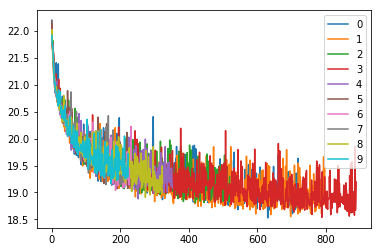

In [20]:
for i in range(10):
    plt.plot(np.log(models_mse_hist[i]['val_loss']), label = str(i))
    print(len(models_mse_hist[i]['loss']))

plt.legend()             
plt.show()

#### MAE Training

In [21]:
# Either load existing parameters
N_ensembles = 10


# Create Multiple RNNs with identical configuration
models_mae_hist = {}
models_mae = create_multiple_rnn_models(number=N_ensembles, model_input=INPUT,widths_rnn =[n_output], 
                                  widths_ffn = [n_output], 
                                   dense_act_fct = 'tanh', optimizer_type='adam', loss_type='mae', 
                                   metric_type='mae', dropout_share=0, 
                                   lambda_layer = True, lambda_scale =V_max, log_scale=True, 
                                    model_compile = True, return_option = 'model', branch_name = '')

if os.path.isfile(wd_rnn+r'\mae\model_0.h5') & dummy_load_saved_models:
    # load model weights
    for i in range(N_ensembles):
        models_mae[i].load_weights(wd_rnn+r'\mae\model_{}.h5'.format(i))
        with open(wd_rnn+r'\mae\model_{}_hist.json'.format(i), 'rb') as f:
            models_mae_hist[i] = pickle.load(f)
        
# Or train model    
else:
    # Train multiple RNNs with identical configuration
    models_mae, models_mae_hist = train_individual_ensembles(models_mae, data_train_sc, targets_train, 
                                                    n_epochs= N_epochs, 
                                                    n_batch= BATCH, es_patience= es_patience,
                                                    path = wd_rnn+r'\mae')
    # Save Model (and History) is integrated in function 'train_individual_ensembles'

731
798
520
889
353
241
237
209
324
224


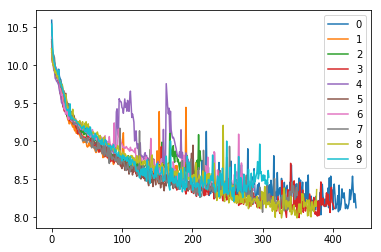

In [22]:
for i in range(10):
    plt.plot(np.log(models_mae_hist[i]['val_loss']), label = str(i))
    print(len(models_mse_hist[i]['loss']))

plt.legend()             
plt.show()

In [85]:
models_mae[0].summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 5)                 0         
_________________________________________________________________
repeat_vector_11 (RepeatVect (None, 43, 5)             0         
_________________________________________________________________
RNN_01 (CuDNNLSTM)           (None, 43)                8600      
_________________________________________________________________
Dense_01 (Dense)             (None, 43)                1892      
_________________________________________________________________
tanh0 (Activation)           (None, 43)                0         
_________________________________________________________________
Log_Scaling_Layer0 (Lambda)  (None, 43)                0         
Total params: 10,492
Trainable params: 10,492
Non-trainable params: 0
_________________________________________________________________


In [86]:
plot_model(models_mae[0], to_file='Prediction_DC_Architecture.png', show_shapes=True,show_layer_names=True)

## 4.2. Ensemble(s)

In [24]:
# Fix Number of Ensembles used
N_ensembles = 5
N_epochs_ensemble = 300
dummy_load_saved_models_ensembles = True
wd_ensembles = cd +r'\ipynb_Checkpoints\Ensembles'
batchsize = 64
es_patience = 50

#### Ensembles: 5, Loss: MSE (V0)

In [25]:
# Either load existing parameters
N_ensembles = 5

# combine models to a single model using an ensemble approach (no qualitative Model included)
ensemble_mse_5 = combine_models(input_layer=INPUT, n_ensembles= N_ensembles, load_weights= True, 
                                weights_ensembles = multiple_models_get_weights(models_mse), 
                                scale = V_max,
                               LSTM_nodes= [n_output], FFN_nodes= [n_output], dense_act_fct= 'tanh')    

In [26]:
#### Ensembles: 5, Loss: MAE (V1)
N_ensembles = 10

# combine models to a single model using an ensemble approach (no qualitative Model included)
ensemble_mse_10 = combine_models(input_layer=INPUT, n_ensembles= N_ensembles, load_weights= True, 
                                weights_ensembles = multiple_models_get_weights(models_mse), 
                                scale = V_max,
                               LSTM_nodes= [n_output], FFN_nodes= [n_output], dense_act_fct= 'tanh')    

In [27]:
# Either load existing parameters
N_ensembles = 5


# combine models to a single model using an ensemble approach (no qualitative Model included)
ensemble_mae_5 = combine_models(input_layer=INPUT, n_ensembles= N_ensembles, load_weights= True, 
                                weights_ensembles = multiple_models_get_weights(models_mae[0:N_ensembles]), 
                                scale = V_max,
                               LSTM_nodes= [n_output], FFN_nodes= [n_output], dense_act_fct= 'tanh')    

In [28]:
# Either load existing parameters
N_ensembles = 10


# combine models to a single model using an ensemble approach (no qualitative Model included)
ensemble_mae_10 = combine_models(input_layer=INPUT, n_ensembles= N_ensembles, load_weights= True, 
                                weights_ensembles = multiple_models_get_weights(models_mae[0:N_ensembles]), 
                                scale = V_max,
                               LSTM_nodes= [n_output], FFN_nodes= [n_output], dense_act_fct= 'tanh')    

In [29]:
# Mixed 5

N_ensembles = 5
ensemble_mse_mae_5 =combine_models(input_layer=INPUT, n_ensembles= N_ensembles, load_weights= True, 
                                weights_ensembles = multiple_models_get_weights(
                                                        models_mse[0:3]+models_mae[0:2]), 
                                scale = V_max,
                               LSTM_nodes= [n_output], FFN_nodes= [n_output], dense_act_fct= 'tanh')

In [30]:
# Mixed 10

N_ensembles = 10
ensemble_mse_mae_10 =combine_models(input_layer=INPUT, n_ensembles= N_ensembles, load_weights= True, 
                                weights_ensembles = multiple_models_get_weights(
                                                        models_mse[0:5]+models_mae[0:5]), 
                                scale = V_max,
                               LSTM_nodes= [n_output], FFN_nodes= [n_output], dense_act_fct= 'tanh')

In [109]:
%run functions/statistical_analysis_functions.ipynb

## 4.3. Comparison of Models

In [31]:
results_statistic = create_df_model_comparison(model_single_lst=models_mse[0:2]+models_mae[0:2], 
                                x_test = data_test_sc, y_test= targets_test,  
                               model_ens_lst = [ensemble_mse_5, ensemble_mse_10,
                                                ensemble_mae_5, ensemble_mae_10,
                                                ensemble_mse_mae_5, ensemble_mse_mae_10],
                                names_number= ['5', '10','5', '10','5','10'],#['5']*3 # 
                                names_loss= ['MSE', 'MSE','MAE','MAE', 'Mixed','Mixed'],# 'MAE'],#'MSE','MAE', 'MAE', 'Mixed'], 
                                names_loss_single = ['MSE']*2+['MAE']*2)

In [32]:
results_statistic[0].style.set_properties(subset=['$pc_{0.99, |wre_t|}$'], **{'width': '65px'})

,Loss,$N_{Ens}$,$\overline{e}_t$,"$pc_{0.99, |e_t|}$",$\overline{wre}_t$,"$pc_{0.99, |wre_t|}$"
Model 0,MSE,1,-2.4e+02,2.3e+04,4.9e-09,4.3e-06
Model 1,MSE,1,5.7e+02,2.2e+04,5.7e-08,4.4e-06
Model 2,MAE,1,-7.6e+02,3.6e+04,-8.7e-07,7.4e-06
Model 3,MAE,1,3.5e+02,7.4e+04,-6.6e-07,1.5e-05
Ensemble 0,MSE,5,1.8e+02,2.1e+04,5e-08,3.8e-06
Ensemble 1,MSE,10,39,2.6e+04,3.6e-08,4.5e-06
Ensemble 2,MAE,5,-3.7e+02,5.8e+04,-8e-07,1.1e-05
Ensemble 3,MAE,10,-3.8e+02,4.9e+04,-8.1e-07,9.6e-06
Ensemble 4,Mixed,5,-30,3.2e+04,-2.8e-07,6e-06
Ensemble 5,Mixed,10,-97,3.8e+04,-3.8e-07,7.4e-06


In [40]:
with open('Prediction_DC_Model_Comparison.tex','w') as tf:
    tf.write(results_statistic[0].to_latex())

In [37]:
stat_ENS_0 = model_examine_indivual_fit(model = ensemble_mse_5, data = data_test_sc, 
                           targets = targets_test, output_option = 'statistic', PV_max= V_max,
                                       interval_lst= [0, 0.005, 0.01, 0.2, 0.4, 0.6, 0.8,1])
stat_ENS_0

,0-0.005,0.005-0.01,0.01-0.2,0.2-0.4,0.4-0.6,0.6-0.8,0.8-1
$\overline{re}_t$,1.02,0.36,9.37e-03,8.95e-04,2.80e-04,1.86e-04,6.41e-04
"$pc_{0.99, |re_t|}$",9.10,1.55,1.68e-01,4.27e-02,2.34e-02,1.95e-02,1.00e-02


In [41]:
with open('Prediction_DC_Model_MSE_5.tex','w') as tf:
    tf.write(stat_ENS_0.to_latex())

In [39]:
stat_ENS_1 = model_examine_indivual_fit(model = ensemble_mae_5, data = data_test_sc, 
                           targets = targets_test, output_option = 'statistic', PV_max= V_max,
                                       interval_lst= [0, 0.005, 0.01, 0.2, 0.4, 0.6, 0.8,1])
stat_ENS_1

,0-0.005,0.005-0.01,0.01-0.2,0.2-0.4,0.4-0.6,0.6-0.8,0.8-1
$\overline{re}_t$,0.36,0.13,2.64e-03,-1.19e-03,-3.84e-03,-7.69e-03,-0.01
"$pc_{0.99, |re_t|}$",3.74,0.75,1.00e-01,3.98e-02,3.41e-02,3.46e-02,0.03


In [42]:
with open('Prediction_DC_Model_MAE_5.tex','w') as tf:
    tf.write(stat_ENS_1.to_latex())

# 5. Grouping

In [43]:
# Ensemble to integrate in Clustering procedure, Choose EP with 5 Sub-Models
model_supervision_clustering =  ensemble_mae_5 #pensions_m0 #
optimizer_cl = Adadelta(lr = 0.1, decay = 0.0)#'adam' #
loss_type_cl = 'mse'
# Path
wd_cluster = cd+r'\ipynb_Checkpoints\Grouping'

#n_timesteps, n_features, n_output = dur_max+1,n_in, dur_max+1
N_epochs_clustering = 30000
es_patience_clustering = 100
load_agg_model = True

In [44]:
%run functions/clustering.ipynb
%run functions/rnn_functions.ipynb
%run functions/visualization_functions.ipynb
%run functions/actuarial_functions.ipynb
%run functions/statistical_analysis_functions.ipynb

## 5.1 100 Clusters

In [45]:
## Baseline, Parameters
N_clusters = 100

# k_means Cluster Procedure
# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters)):
    # load model weights
    with open(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters), 'rb') as input:
        kMeans_100 = pickle.load(input)
else:
    # perform clustering
    kMeans_100 = cluster.MiniBatchKMeans(n_clusters=N_clusters, batch_size=BATCH, verbose =0).fit(data_sc);
    # save result
    with open(wd_cluster+r'\kMeans_Baseline' + '\kMeans_{}.pkl'.format(N_clusters), 'wb') as output:
        pickle.dump(kMeans_100, output, pickle.HIGHEST_PROTOCOL)

In [51]:
## Data
N_clusters = 100

# Utilize k-Means Clustering pre-processing
# Devide Data in k clusters
data_lst_cluster_100 = []
targets_lst_cluster_100 = []
for i in range(N_clusters):
    index = kMeans_100.labels_ == i
    data_lst_cluster_100.append(data_sc[index,].reshape((1,index.sum(),n_in)))
    targets_lst_cluster_100.append((targets[index,].sum(axis=0)/index.sum()).reshape(1,n_output))

In [53]:
os.path.isfile(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl')#&load_agg_model

False

In [54]:
## Apply ANN
N_clusters = 100

# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl')&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'rb') as input:
        cluster_analysis_100 = pickle.load(input)
else:
    # perform agglomeration by ANN
    cluster_analysis_100 = cluster_ann_test(y_lst = targets_lst_cluster_100, 
                                      model_prediction = model_supervision_clustering, 
                                      N_ensembles= 5, N_features = n_in, scale = V_max,
                                      N_centroids= 1,
                                      optimizer = optimizer_cl, loss_type = 'mse', metric_type = 'mae',
                                      option_centroid= True, init_centroids= kMeans_100.cluster_centers_,
                                      cluster_member_count= kmeans_counts(kMeans_100.labels_, clusters= N_clusters),
                                      N_epochs = N_epochs_clustering, 
                                      es_patience= es_patience_clustering,
                                      option_es = True, option_log_scaling = False,
                                      wd_cluster = wd_cluster +'\K_{}'.format(N_clusters))
    # save agglomeration object
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'wb') as output:
        pickle.dump(cluster_analysis_100, output, pickle.HIGHEST_PROTOCOL)

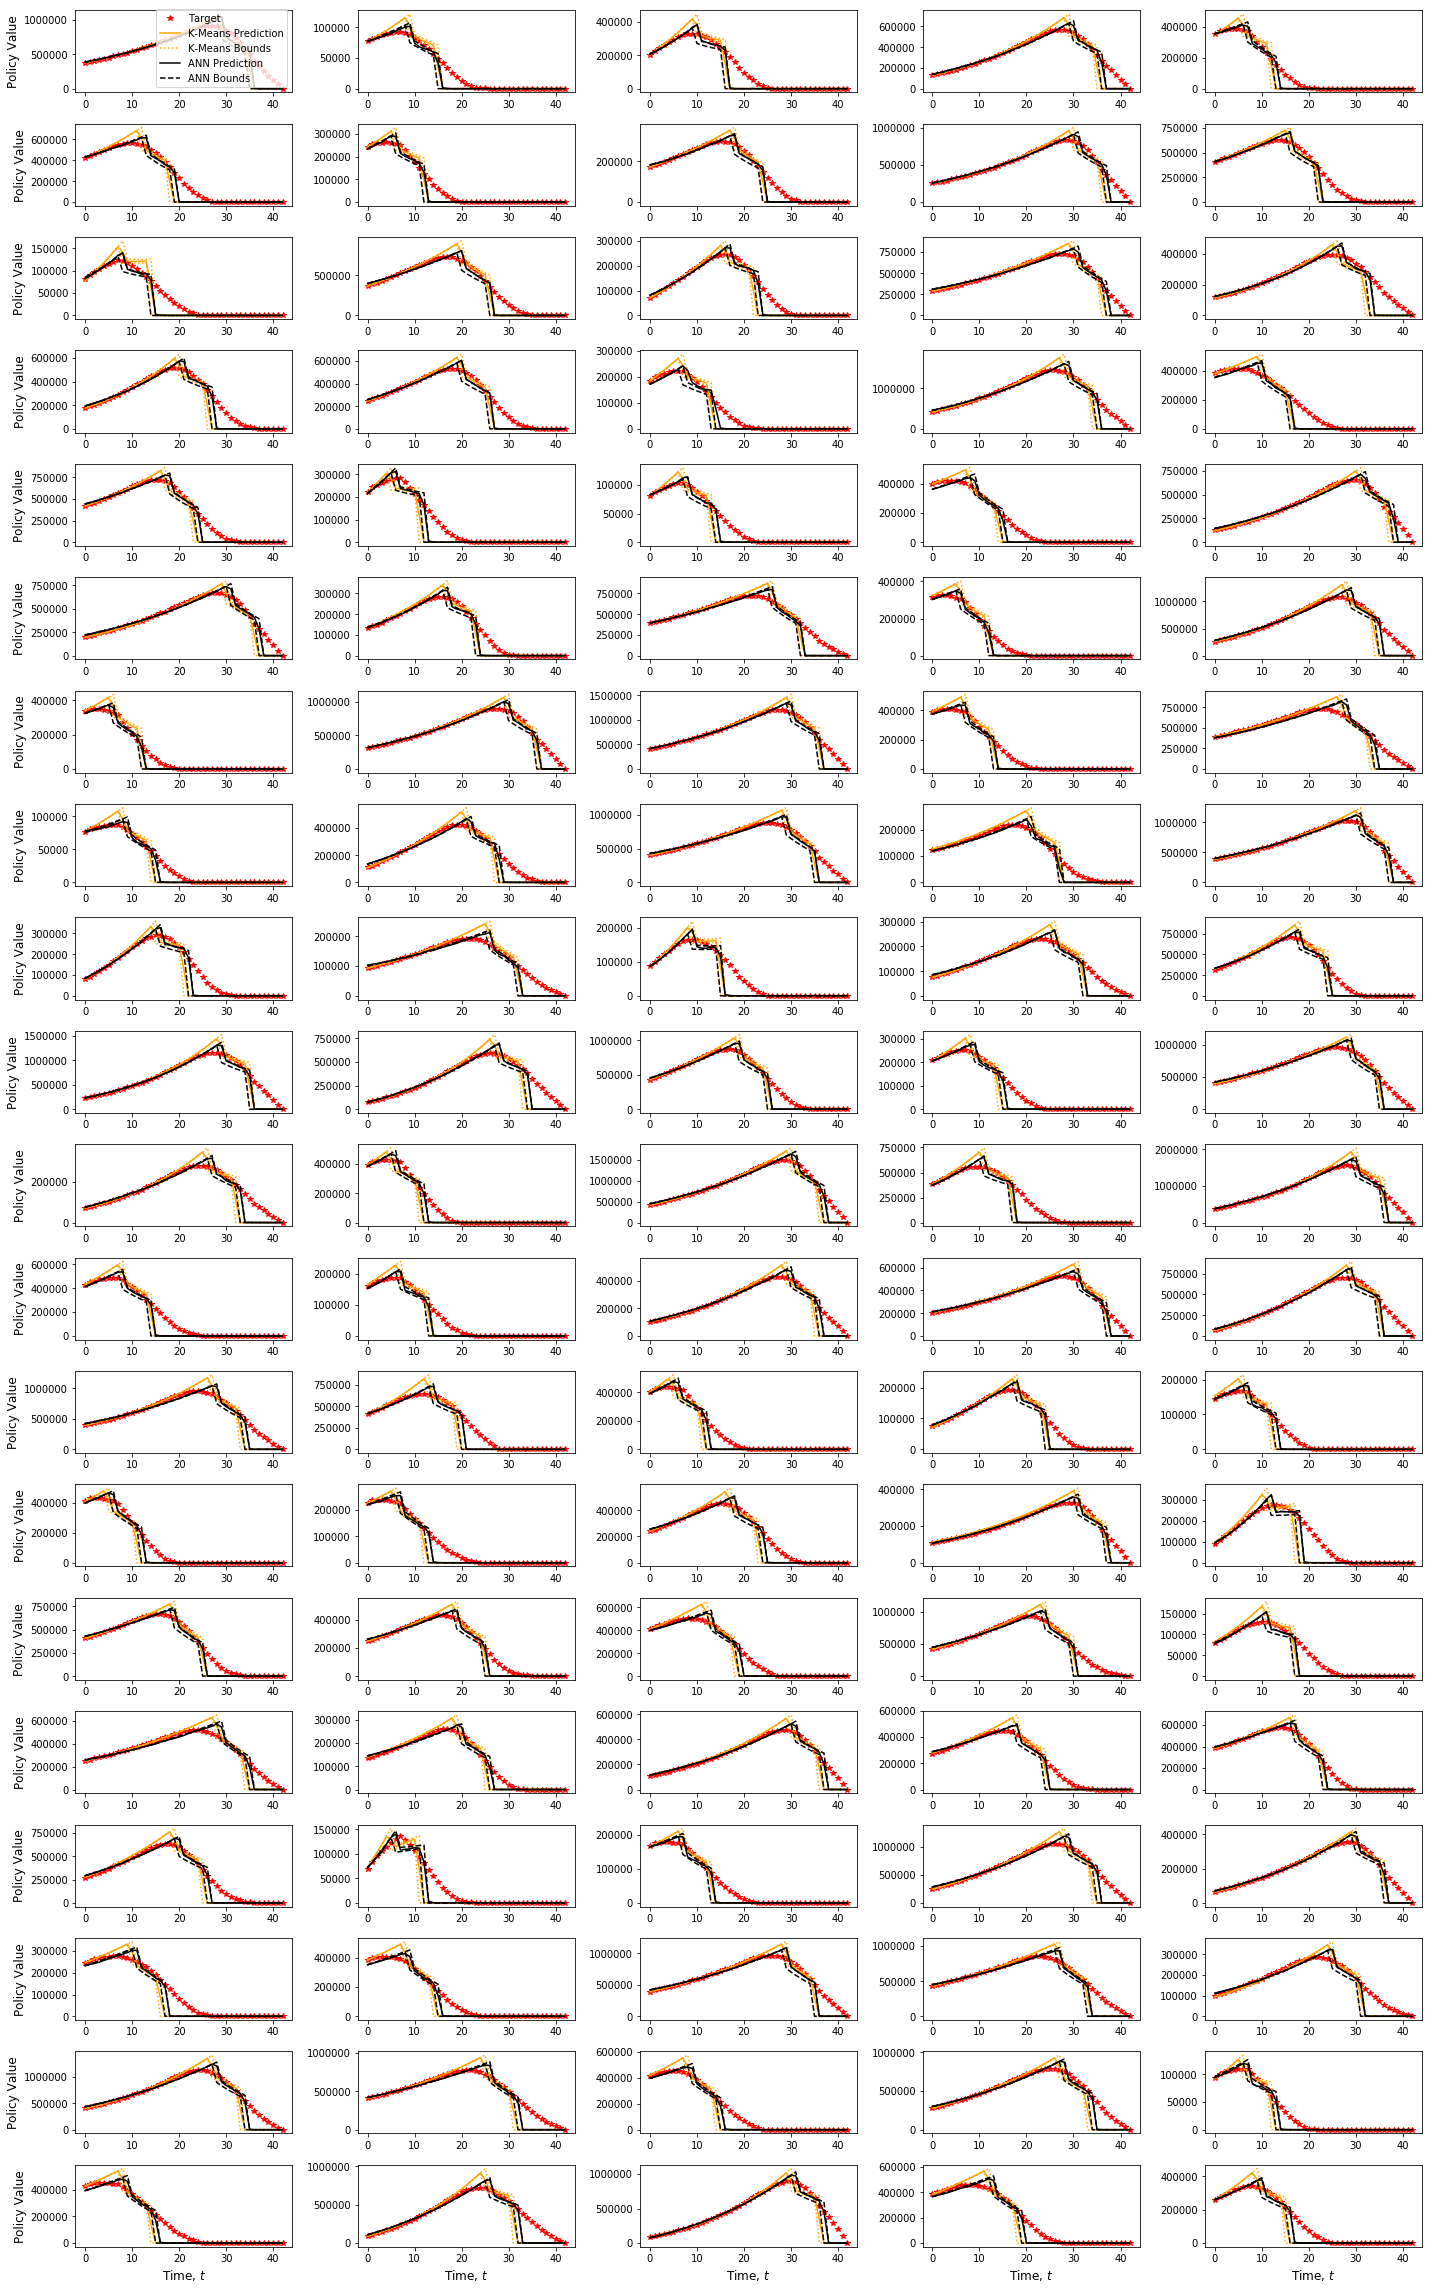

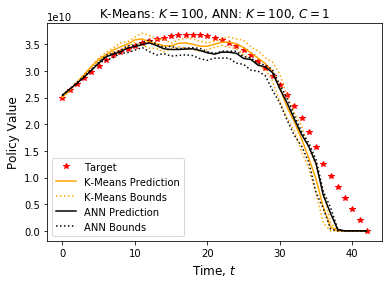

In [55]:
analyze_agglomeration_test(baseline = kMeans_100, y = targets_lst_cluster_100, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_100[1], 
                      ann_cluster_presort= kMeans_100,
                      ann_representatives= cluster_analysis_100[0], individual_clusters=True,
                      figsize = (20,32), insurance_type= 'pensions', pension_age_max= pension_age_max)

,$\overline{re}_t$,$\overline{e}_t$
$K$-means Prediction,-0.16,-1.42e+09
ANN Prediction,-0.16,-1.75e+09
ANN Bound (up),-0.14,-1.43e+09
ANN Bound (low),-0.21,-3.02e+09


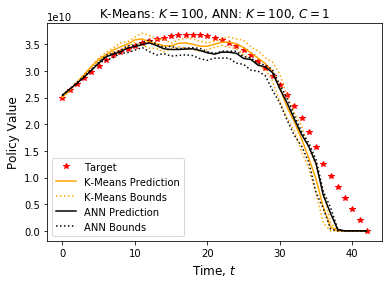

In [56]:
stat_100 = analyze_agglomeration_test(baseline = kMeans_100, y = targets, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_100[1], 
                      ann_cluster_presort= kMeans_100,
                      ann_representatives= cluster_analysis_100[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                       option= 'statistic',
                      n_columns= 1, option_header = True,
                      figsize = (8,5), insurance_type= 'pensions', pension_age_max= pension_age_max)

stat_100[0]

## 5.2. 50 Clusters

In [ ]:
## Baseline, Parameters
N_clusters = 50

# k_means Cluster Procedure
# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters)):
    # load model weights
    with open(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters), 'rb') as input:
        kMeans_50 = pickle.load(input)
else:
    # perform clustering
    kMeans_50 = cluster.MiniBatchKMeans(n_clusters=N_clusters, batch_size=BATCH, verbose =0).fit(data_sc);
    # save result
    with open(wd_cluster+r'\kMeans_Baseline' + '\kMeans_{}.pkl'.format(N_clusters), 'wb') as output:
        pickle.dump(kMeans_50, output, pickle.HIGHEST_PROTOCOL)

In [ ]:
## Data
N_clusters = 50

# Utilize k-Means Clustering pre-processing
# Devide Data in k clusters
data_lst_cluster_50 = []
targets_lst_cluster_50 = []
for i in range(N_clusters):
    index = kMeans_50.labels_ == i
    data_lst_cluster_50.append(data_sc[index,].reshape((1,index.sum(),n_in)))
    targets_lst_cluster_50.append((targets[index,].sum(axis=0)/index.sum()).reshape(1,n_output))

In [ ]:
## Apply ANN
N_clusters = 50

# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl')&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'rb') as input:
        cluster_analysis_50 = pickle.load(input)
else:
    # perform agglomeration by ANN # Check if N_ensemble matches supervision model
    cluster_analysis_50 = cluster_ann_test(y_lst = targets_lst_cluster_50, 
                                      model_prediction = model_supervision_clustering, 
                                      N_ensembles= 5, N_features = n_in, scale = V_max,
                                      N_centroids= 1,
                                      optimizer = optimizer_cl, loss_type = 'mse', metric_type = 'mae',
                                      option_centroid= True, init_centroids= kMeans_50.cluster_centers_,
                                      cluster_member_count= kmeans_counts(kMeans_50.labels_, clusters= N_clusters),
                                      N_epochs = N_epochs_clustering, 
                                      es_patience= es_patience_clustering,
                                      option_es = True, option_log_scaling = False,
                                      wd_cluster = wd_cluster +'\K_{}'.format(N_clusters))
    # save agglomeration object
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'wb') as output:
        pickle.dump(cluster_analysis_50, output, pickle.HIGHEST_PROTOCOL)

In [ ]:
analyze_agglomeration_test(baseline = kMeans_50, y = targets_lst_cluster_50, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_50[1],
                      ann_cluster_presort= kMeans_50,
                      ann_representatives= cluster_analysis_50[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                      figsize = (20,12), insurance_type= 'pensions', pension_age_max= pension_age_max)

,$\overline{re}_t$,$\overline{e}_t$
$K$-means,-0.17,-1.65e+09
ANN Prediction,-0.17,-2.11e+09
ANN Bound (up),-0.16,-1.84e+09
ANN Bound (low),-0.23,-3.39e+09


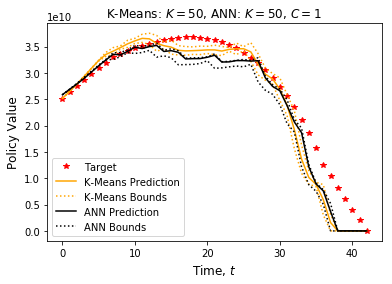

In [475]:
stat_50 = analyze_agglomeration_test(baseline = kMeans_50, y = targets, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_50[1], 
                      ann_cluster_presort= kMeans_50,
                      ann_representatives= cluster_analysis_50[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                       option= 'statistic',
                      n_columns= 1, option_header = True,
                      figsize = (8,5), insurance_type= 'pensions', pension_age_max= pension_age_max)

stat_50[0]

50

## 5.3. 25 Clusters

In [79]:
## Baseline, Parameters
N_clusters = 25

# k_means Cluster Procedure
# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters))&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters), 'rb') as input:
        kMeans_25 = pickle.load(input)
else:
    # perform clustering
    kMeans_25 = cluster.MiniBatchKMeans(n_clusters=N_clusters, batch_size=BATCH, verbose =0).fit(data_sc);
    # save result
    with open(wd_cluster+r'\kMeans_Baseline' + '\kMeans_{}.pkl'.format(N_clusters), 'wb') as output:
        pickle.dump(kMeans_25, output, pickle.HIGHEST_PROTOCOL)

In [ ]:
## Data
N_clusters = 25

# Utilize k-Means Clustering pre-processing
# Devide Data in k clusters
data_lst_cluster_25 = []
targets_lst_cluster_25 = []
for i in range(N_clusters):
    index = kMeans_25.labels_ == i
    data_lst_cluster_25.append(data_sc[index,].reshape((1,index.sum(),n_in)))
    targets_lst_cluster_25.append((targets[index,].sum(axis=0)/index.sum()).reshape(1,n_output))

In [ ]:
## Apply ANN
N_clusters = 25

# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl')&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'rb') as input:
        cluster_analysis_25 = pickle.load(input)
else:
    # perform agglomeration by ANN # Check if N_ensemble matches supervision model
    cluster_analysis_25 = cluster_ann_test(y_lst = targets_lst_cluster_25, 
                                      model_prediction = model_supervision_clustering, 
                                      N_ensembles= 5, N_features = n_in, scale = V_max,
                                      N_centroids= 1,
                                      optimizer = optimizer_cl, loss_type = 'mse', metric_type = 'mae',
                                      option_centroid= True, init_centroids= kMeans_25.cluster_centers_,
                                      cluster_member_count= kmeans_counts(kMeans_25.labels_, clusters= N_clusters),
                                      N_epochs = N_epochs_clustering, 
                                      es_patience= es_patience_clustering,
                                      option_es = True, option_log_scaling = False,
                                      wd_cluster = wd_cluster +'\K_{}'.format(N_clusters))
    # save agglomeration object
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object.pkl', 'wb') as output:
        pickle.dump(cluster_analysis_25, output, pickle.HIGHEST_PROTOCOL)

In [ ]:
analyze_agglomeration_test(baseline = kMeans_25, y = targets_lst_cluster_25, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_25[1],
                      ann_cluster_presort= kMeans_25,
                      ann_representatives= cluster_analysis_25[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                      figsize = (20,12), insurance_type= 'pensions', pension_age_max= pension_age_max)

,$\overline{re}_t$,$\overline{e}_t$
$K$-means,-0.21,-2.12e+09
ANN Prediction,-0.22,-2.86e+09
ANN Bound (up),-0.21,-2.67e+09
ANN Bound (low),-0.27,-4.17e+09


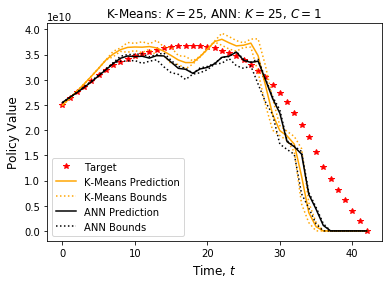

In [471]:
stat_25 = analyze_agglomeration_test(baseline = kMeans_25, y = targets, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_25[1], 
                      ann_cluster_presort= kMeans_25,
                      ann_representatives= cluster_analysis_25[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                       option= 'statistic',
                      n_columns= 1, option_header = True,
                      figsize = (8,5), insurance_type= 'pensions', pension_age_max= pension_age_max)

stat_25[0]#.style.set_properties(subset=[r'$CL_{0.99,|re{}_t|}$'], **{'width': '60px'})

ValueError: x and y must be the same size

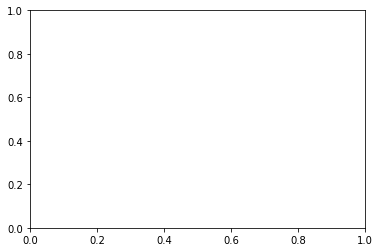

In [236]:
visualize_representatives_km_ann(km_rep = kMeans_25.cluster_centers_, 
                                 ann_rep = cluster_analysis_25[0], features= input_used,
                                option= 'test')

In [228]:
ann_rep = cluster_analysis_25[0]
i = 0
n_length = len(ann_rep)
[ann_rep[k][:,i] for k in range(n_length)]

TypeError: list indices must be integers or slices, not tuple

In [234]:
ann_rep[0][0][0,0]

0.36849162

In [235]:
%run functions/visualization_functions.ipynb

## 5.5. 10 Clusters

In [77]:
%run functions/clustering.ipynb

### MSE Prediction Model

In [57]:
## Baseline, Parameters
N_clusters = 10

# k_means Cluster Procedure
# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters))&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters), 'rb') as input:
        kMeans_10 = pickle.load(input)
else:
    # perform clustering
    kMeans_10 = cluster.MiniBatchKMeans(n_clusters=N_clusters, batch_size=BATCH, verbose =0).fit(data_sc);
    # save result
    with open(wd_cluster+r'\kMeans_Baseline' + '\kMeans_{}.pkl'.format(N_clusters), 'wb') as output:
        pickle.dump(kMeans_10, output, pickle.HIGHEST_PROTOCOL)

In [58]:
## Data
N_clusters = 10

# Utilize k-Means Clustering pre-processing
# Devide Data in k clusters
data_lst_cluster_10 = []
targets_lst_cluster_10 = []
for i in range(N_clusters):
    index = kMeans_10.labels_ == i
    data_lst_cluster_10.append(data_sc[index,].reshape((1,index.sum(),n_in)))
    targets_lst_cluster_10.append((targets[index,].sum(axis=0)/index.sum()).reshape(1,n_output))

In [59]:
## Apply ANN
N_clusters = 10

# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_mse.pkl')&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_mse.pkl', 'rb') as input:
        cluster_analysis_10_mse = pickle.load(input)
else:
    cluster_analysis_10_mse = cluster_ann_test(y_lst = targets_lst_cluster_10, 
                                      model_prediction = ensemble_mse_5, 
                                      N_ensembles= 5, N_features = n_in, scale = V_max,
                                      N_centroids= 1,
                                      optimizer = optimizer_cl, loss_type = 'mse', metric_type = 'mae',
                                      option_centroid= True, init_centroids= kMeans_10.cluster_centers_,
                                      cluster_member_count= kmeans_counts(kMeans_10.labels_, clusters= N_clusters),
                                      N_epochs = N_epochs_clustering, 
                                      es_patience= es_patience_clustering,
                                      option_es = False, option_log_scaling = False,
                                      wd_cluster = wd_cluster +'\K_{}'.format(N_clusters))
    
    
    # save agglomeration object
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_mse.pkl', 'wb') as output:
        pickle.dump(cluster_analysis_10_mse, output, pickle.HIGHEST_PROTOCOL)

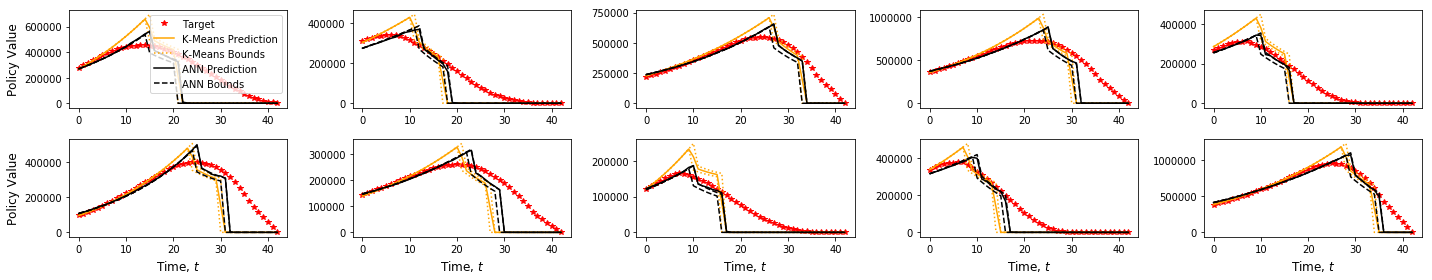

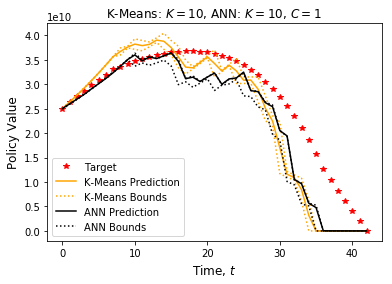

In [60]:
analyze_agglomeration_test(baseline = kMeans_10, y = targets_lst_cluster_10, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_10_mse[1],
                           ann_cluster_presort= kMeans_10,
                      ann_representatives= cluster_analysis_10_mse[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                      figsize = (20,4), insurance_type= 'pensions', pension_age_max= pension_age_max)

,$\overline{re}_t$,$\overline{e}_t$
$K$-means Prediction,-0.24,-3.11e+09
ANN Prediction,-0.26,-3.88e+09
ANN Bound (up),-0.26,-3.83e+09
ANN Bound (low),-0.31,-5.28e+09


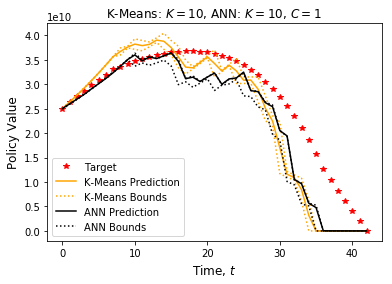

In [61]:
stat_10_mse = analyze_agglomeration_test(baseline = kMeans_10, y = targets, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_10_mse[1], 
                      ann_cluster_presort= kMeans_10,
                      ann_representatives= cluster_analysis_10_mse[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                       option= 'statistic',
                      n_columns= 1, option_header = True,
                      figsize = (8,5), insurance_type= 'pensions', pension_age_max= pension_age_max)
stat_10_mse[0]#.style.set_properties(subset=[r'$CL_{0.99,|re{}_t|}$'], **{'width': '60px'})

### MAE Prediction Model

In [62]:
## Apply ANN
N_clusters = 10

# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_mae.pkl')&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_mae.pkl', 'rb') as input:
        cluster_analysis_10_mae = pickle.load(input)
else:
    cluster_analysis_10_mae = cluster_ann_test(y_lst = targets_lst_cluster_10, 
                                      model_prediction = ensemble_mae_5, 
                                      N_ensembles= 5, N_features = n_in, scale = V_max,
                                      N_centroids= 1,
                                      optimizer = optimizer_cl, loss_type = 'mse', metric_type = 'mae',
                                      option_centroid= True, init_centroids= kMeans_10.cluster_centers_,
                                      cluster_member_count= kmeans_counts(kMeans_10.labels_, clusters= N_clusters),
                                      N_epochs = N_epochs_clustering, 
                                      es_patience= es_patience_clustering,
                                      option_es = False, option_log_scaling = False,
                                      wd_cluster = wd_cluster +'\K_{}'.format(N_clusters))
    
    
    # save agglomeration object
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_mae.pkl', 'wb') as output:
        pickle.dump(cluster_analysis_10_mae, output, pickle.HIGHEST_PROTOCOL)

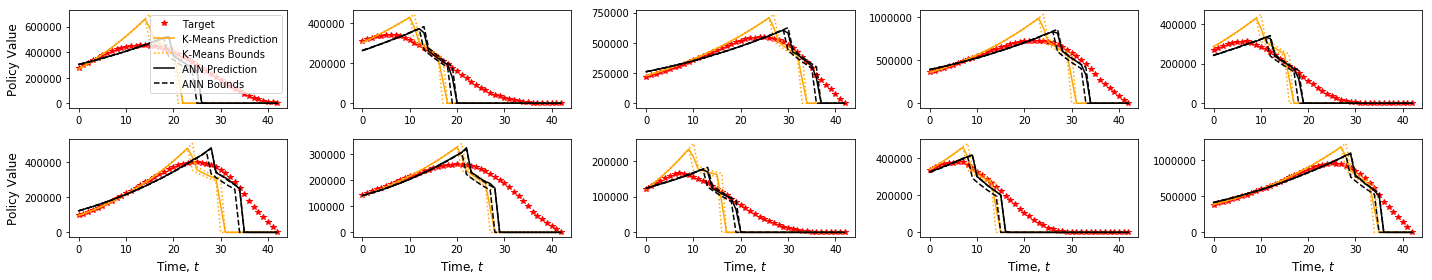

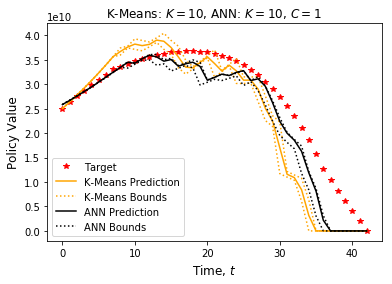

In [63]:
analyze_agglomeration_test(baseline = kMeans_10, y = targets, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_10_mae[1],
                           ann_cluster_presort= kMeans_10,
                      ann_representatives= cluster_analysis_10_mae[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                      figsize = (20,4), insurance_type= 'pensions', pension_age_max= pension_age_max)

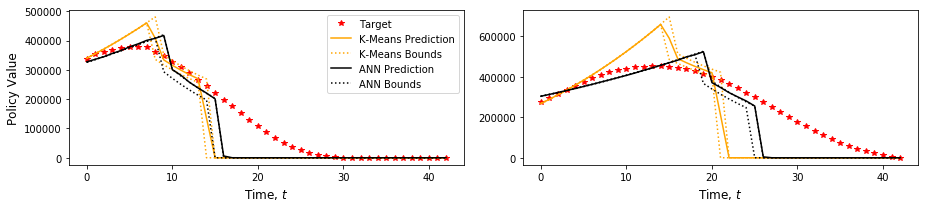

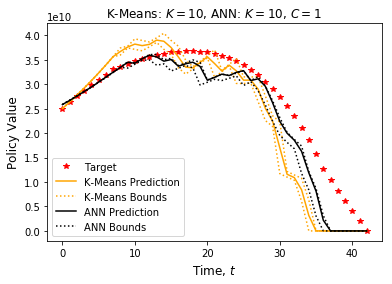

In [64]:
analyze_agglomeration_test(baseline = kMeans_10, y = targets, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_10_mae[1],
                           ann_cluster_presort= kMeans_10,
                      ann_representatives= cluster_analysis_10_mae[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                           option_plot_selection= [8,0], n_columns = 2, figsize = (13,3),
                      insurance_type= 'pensions', pension_age_max= pension_age_max)

,$\overline{re}_t$,$\overline{e}_t$
$K$-means Prediction,-0.24,-3.11e+09
ANN Prediction,-0.21,-2.75e+09
ANN Bound (up),-0.20,-2.57e+09
ANN Bound (low),-0.26,-3.95e+09


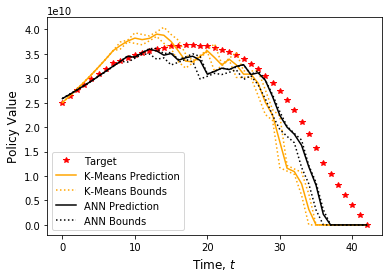

In [65]:
stat_10_mae = analyze_agglomeration_test(baseline = kMeans_10, y = targets, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_10_mae[1], 
                      ann_cluster_presort= kMeans_10,
                      ann_representatives= cluster_analysis_10_mae[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                       option= 'statistic',
                      n_columns= 1, option_header = False,
                      figsize = (8,5), insurance_type= 'pensions', pension_age_max= pension_age_max)
stat_10_mae[0]#.style.set_properties(subset=[r'$CL_{0.99,|re{}_t|}$'], **{'width': '60px'})

In [66]:
with open('Grouping_DC_K10.tex','w') as tf:
    tf.write(stat_10_mae[0].to_latex())

In [105]:
for i in range(10):
    print(len(cluster_analysis_10_mae[-1][i]['loss']))

30000
30000
30000
30000
30000
30000
30000
30000
30000
30000


TypeError: unhashable type: 'slice'

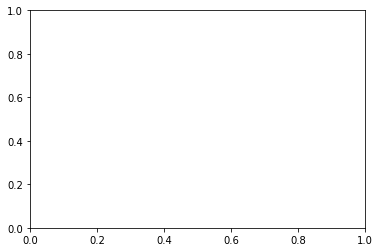

In [89]:
visualize_representatives_km_ann(km_rep = kMeans_10.cluster_centers_, 
                                 ann_rep = cluster_analysis_10[0], features= input_used)

## 5.6. 5 Cluster - K-means presort

In [69]:
## Baseline, Parameters
N_clusters = 5

# k_means Cluster Procedure
# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters))&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters), 'rb') as input:
        kMeans_5 = pickle.load(input)
else:
    # perform clustering
    kMeans_5 = cluster.MiniBatchKMeans(n_clusters=N_clusters, batch_size=BATCH, verbose =0).fit(data_sc);
    # save result
    with open(wd_cluster+r'\kMeans_Baseline' + '\kMeans_{}.pkl'.format(N_clusters), 'wb') as output:
        pickle.dump(kMeans_5, output, pickle.HIGHEST_PROTOCOL)

In [70]:
## Data
N_clusters = 5

# Utilize k-Means Clustering pre-processing
# Devide Data in k clusters
data_lst_cluster_5 = []
targets_lst_cluster_5 = []
for i in range(N_clusters):
    index = kMeans_5.labels_ == i
    data_lst_cluster_5.append(data_sc[index,].reshape((1,index.sum(),n_in)))
    targets_lst_cluster_5.append((targets[index,].sum(axis=0)/index.sum()).reshape(1,n_output))

## 5.7. 1 Cluster - K-means "presort"

In [71]:
## Baseline, Parameters
N_clusters = 1

# k_means Cluster Procedure
# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters))&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\kMeans_Baseline' + '\kmeans_{}.pkl'.format(N_clusters), 'rb') as input:
        kMeans_1 = pickle.load(input)
else:
    # perform clustering
    kMeans_1 = cluster.MiniBatchKMeans(n_clusters=N_clusters, batch_size=BATCH, verbose =0).fit(data_sc);
    # save result
    with open(wd_cluster+r'\kMeans_Baseline' + '\kMeans_{}.pkl'.format(N_clusters), 'wb') as output:
        pickle.dump(kMeans_1, output, pickle.HIGHEST_PROTOCOL)

In [72]:
## Data
N_clusters = 1

# Utilize k-Means Clustering pre-processing
# Devide Data in k clusters
data_lst_cluster_1 = []
targets_lst_cluster_1 = []
for i in range(N_clusters):
    index = kMeans_1.labels_ == i
    data_lst_cluster_1.append(data_sc[index,].reshape((1,index.sum(),n_in)))
    targets_lst_cluster_1.append((targets[index,].sum(axis=0)/index.sum()).reshape(1,n_output))

In [73]:
%run functions/clustering.ipynb

## 10 Clusters - Multiple Centroids

In [36]:
## Apply ANN
N_clusters = 10
N_centroids = 2

# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_2.pkl')&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_2.pkl', 'rb') as input:
        cluster_analysis_10_2 = pickle.load(input)
else:
    # perform agglomeration by ANN
    # Check whether N_ensembles and model_supervision_clustering match
    cluster_analysis_10_2 = cluster_ann_test(y_lst = targets_lst_cluster_10, 
                                      model_prediction = model_supervision_clustering, 
                                      N_ensembles= 5, N_features = n_in, scale = V_max,
                                      N_centroids= N_centroids,
                                      optimizer = 'adam', loss_type = 'mse', metric_type = 'mae',
                                      option_centroid= True, init_centroids= kMeans_10.cluster_centers_,
                                      #input_option_cluster_scale= True, 
                                    cluster_member_count= kmeans_counts(kMeans_10.labels_, clusters= N_clusters),
                                      N_epochs = N_epochs_clustering, es_patience= es_patience_clustering,
                                      option_es = True, option_log_scaling = False,
                                      wd_cluster = wd_cluster +'\K_{}'.format(N_clusters))
    # save agglomeration object
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_2.pkl', 'wb') as output:
        pickle.dump(cluster_analysis_10_2, output, pickle.HIGHEST_PROTOCOL)

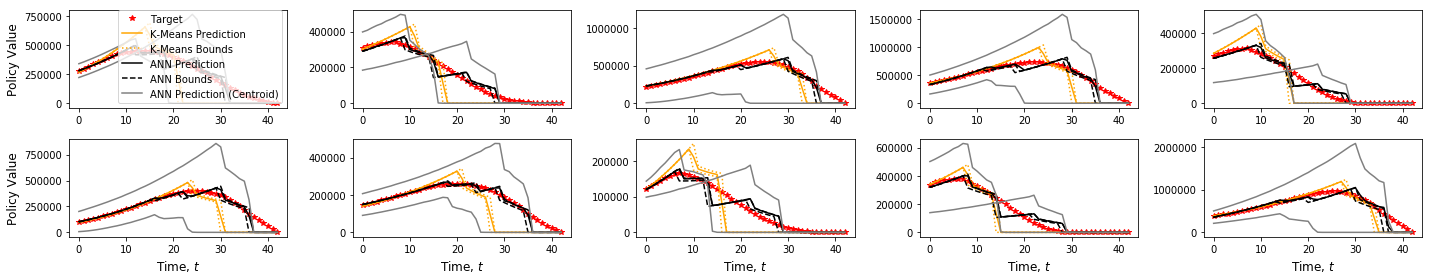

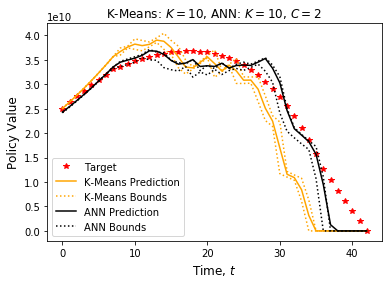

In [64]:
analyze_agglomeration_test(baseline = kMeans_10, y = targets, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_10_2[1],
                           ann_cluster_presort= kMeans_10,
                      ann_representatives= cluster_analysis_10_2[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                      figsize = (20,4), insurance_type= 'pensions', pension_age_max= pension_age_max)

In [70]:
for i in range(10):
    print(len(cluster_analysis_10_2[-1][i]['loss']))

1701
20541
19614
20544
25474
18858
25868
26863
25145
23412


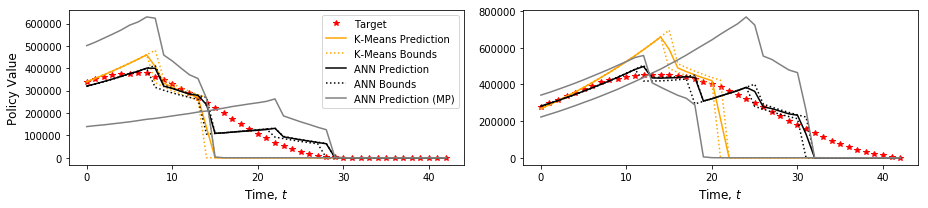

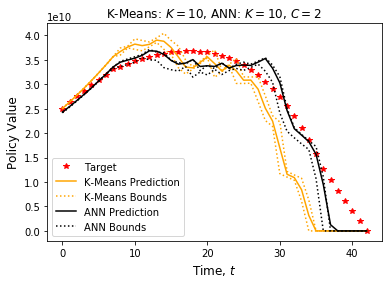

In [39]:
analyze_agglomeration_test(baseline = kMeans_10, y = targets, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_10_2[1],
                           ann_cluster_presort= kMeans_10,
                      ann_representatives= cluster_analysis_10_2[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                           option_plot_selection= [8,0], n_columns= 2,
                      figsize = (13,3), insurance_type= 'pensions', pension_age_max= pension_age_max)

,$\overline{re}_t$,$\overline{e}_t$
$K$-means,-0.24,-3.11e+09
ANN Prediction,-0.13,-9.75e+08
ANN Bound (up),-0.12,-8.28e+08
ANN Bound (low),-0.19,-2.45e+09


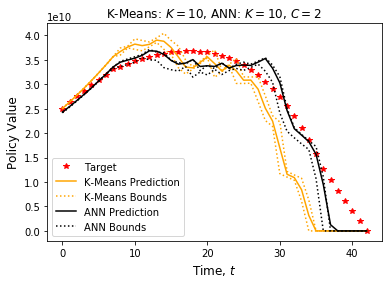

In [69]:
stat_10_2 = analyze_agglomeration_test(baseline = kMeans_10, y = targets, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_10_2[1],
                           ann_cluster_presort= kMeans_10,
                      ann_representatives= cluster_analysis_10_2[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                           option='statistic',
                      figsize = (20,4), insurance_type= 'pensions', pension_age_max= pension_age_max)
stat_10_2[0]

## Grouping with 1 Cluster and 10 Centroids

In [74]:
## Apply ANN
N_clusters = 1
N_centroids = 10

# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_1.pkl')&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_1.pkl', 'rb') as input:
        cluster_analysis_1 = pickle.load(input)
else:
    # perform agglomeration by ANN
    # Check whether N_ensembles and model_supervision_clustering match
    cluster_analysis_1 = cluster_ann_test(y_lst = targets_lst_cluster_1, 
                                      model_prediction = model_supervision_clustering, 
                                      N_ensembles= 5, N_features = n_in, scale = V_max,
                                      N_centroids= N_centroids,
                                      optimizer = optimizer_cl, loss_type = 'mse', metric_type = 'mae',
                                      option_centroid= True, init_centroids= kMeans_1.cluster_centers_,
                                      #input_option_cluster_scale= True, 
                                      cluster_member_count= kmeans_counts(kMeans_1.labels_, clusters= N_clusters),
                                      N_epochs = N_epochs_clustering, es_patience= es_patience_clustering,
                                      option_es = True, option_log_scaling = False,
                                      wd_cluster = wd_cluster +'\K_{}'.format(N_clusters))
    # save agglomeration object
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_1.pkl', 'wb') as output:
        pickle.dump(cluster_analysis_1, output, pickle.HIGHEST_PROTOCOL)

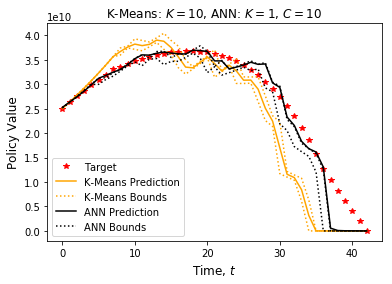

In [75]:
analyze_agglomeration_test(baseline = kMeans_10, y = targets_lst_cluster_10, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_1[1], 
                      ann_representatives= cluster_analysis_1[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                      ann_cluster_presort= kMeans_1,
                      n_columns= 1, option_header = True,
                      figsize = (8,5), insurance_type= 'pensions', pension_age_max= pension_age_max)

,$\overline{re}_t$,$\overline{e}_t$
$K$-means Prediction,-0.24,-3.11e+09
ANN Prediction,-0.12,-7.45e+08
ANN Bound (up),-0.12,-8.09e+08
ANN Bound (low),-0.20,-2.43e+09


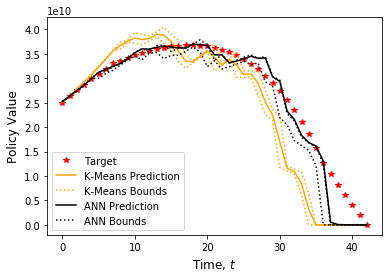

In [82]:
stat_1_10 = analyze_agglomeration_test(baseline = kMeans_10, y = targets, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_1[1], 
                      ann_cluster_presort= kMeans_1,
                      ann_representatives= cluster_analysis_1[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                       option= 'statistic',
                      n_columns= 1, option_header = False,
                      figsize = (8,5), insurance_type= 'pensions', pension_age_max= pension_age_max)
stat_1_10[0]

In [84]:
with open('Grouping_DC_K1_C10.tex','w') as tf:
    tf.write(stat_1_10[0].to_latex())

## Grouping with 5 clusters, each with 5 model points

In [77]:
## Apply ANN
N_clusters = 5
N_centroids = 5

# check if kMeans clustering for given no. of clusters already performed
if os.path.isfile(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_5_5.pkl')&load_agg_model:
    # load model weights
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_5_5.pkl', 'rb') as input:
        cluster_analysis_5_5 = pickle.load(input)
else:
    # perform agglomeration by ANN
    # Check whether N_ensembles and model_supervision_clustering match
    cluster_analysis_5_5 = cluster_ann_test(y_lst = targets_lst_cluster_5, 
                                      model_prediction = model_supervision_clustering, 
                                      N_ensembles= 5, N_features = n_in, scale = V_max,
                                      N_centroids= N_centroids,
                                      optimizer = optimizer_cl, loss_type = 'mse', metric_type = 'mae',
                                      option_centroid= True, init_centroids= kMeans_5.cluster_centers_,
                                      #input_option_cluster_scale= True, 
                                      cluster_member_count= kmeans_counts(kMeans_5.labels_, clusters= N_clusters),
                                      N_epochs = N_epochs_clustering, es_patience= es_patience_clustering,
                                      option_es = True, option_log_scaling = False,
                                      wd_cluster = wd_cluster +'\K_{}'.format(N_clusters))
    # save agglomeration object
    with open(wd_cluster+r'\K_{}'.format(N_clusters) + '\cluster_object_5_5.pkl', 'wb') as output:
        pickle.dump(cluster_analysis_5_5, output, pickle.HIGHEST_PROTOCOL)

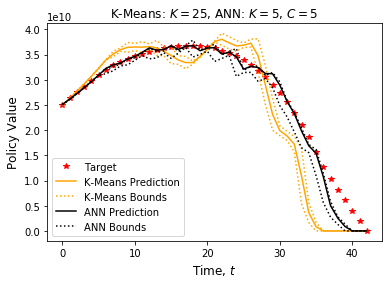

In [80]:
analyze_agglomeration_test(baseline = kMeans_25, y = targets, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_5_5[1], 
                      ann_representatives= cluster_analysis_5_5[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                      ann_cluster_presort= kMeans_5,
                      n_columns= 1, option_header = True,
                      figsize = (8,5), insurance_type= 'pensions', pension_age_max= pension_age_max)


,$\overline{re}_t$,$\overline{e}_t$
$K$-means Prediction,-0.21,-2.12e+09
ANN Prediction,-0.10,-6.09e+08
ANN Bound (up),-0.09,-4.68e+08
ANN Bound (low),-0.17,-2.07e+09


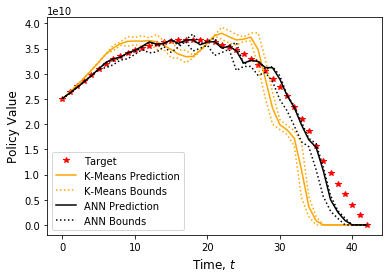

In [81]:
stat_5_5 = analyze_agglomeration_test(baseline = kMeans_25, y = targets, Max_min=Min_Max,
                      include_ann= True, ann_prediction= cluster_analysis_5_5[1], 
                      ann_cluster_presort= kMeans_5,
                      ann_representatives= cluster_analysis_5_5[0], individual_clusters=True,
                      ep_rate= early_pension_structure, interest_rate= interest_rate,
                       option= 'statistic',
                      n_columns= 1, option_header = False,
                      figsize = (8,5), insurance_type= 'pensions', pension_age_max= pension_age_max)
stat_5_5[0]

In [83]:
with open('Grouping_DC_K5_C5.tex','w') as tf:
    tf.write(stat_5_5[0].to_latex())